# Random Forest 

## Example 1 (Manual Toy Dataset)

A single Decision Tree makes one set of splits and commits to them - it can be sensitive to small changes in data (high variance). A Random Forest builds many decision trees, each trained slightly differently, then combines their votes:

Bagging (Bootstrap Aggregating): each tree is trained on a random sample of the data, drawn with replacement (so some rows repeat, some are left out).
Feature randomness: at each split, each tree only considers a random subset of features (not all of them) — this decorrelates the trees so they don't all make the same mistakes.
Voting/averaging: for classification, the final prediction is the majority vote across all trees. For regression, it's the average.

The core idea: many weak, slightly-different, overfitting-prone trees, averaged together, cancel out each other's noise and produce a stronger, more stable prediction than any single tree.

Real-life example

Think of asking 100 different doctors to diagnose a patient, each having seen a slightly different subset of the patient's history and slightly different specialties emphasized. No single doctor is perfect, but the majority opinion across all 100 is usually more reliable than any one doctor's guess - because their individual errors are somewhat random and independent, while the correct signal is shared.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
# Manual toy dataset (same as your Decision Tree example)
tenure = np.array([1,2,5,8,12,20,30,40,50,60]).reshape(-1,1)
churn  = np.array([1,1,1,1,0,0,0,0,0,0])

In [3]:
# Train Random Forest
model = RandomForestClassifier(n_estimators=5, max_depth=2, random_state=42)
model.fit(tenure, churn)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: b

In [4]:
# Predictions
pred = model.predict(tenure)
proba = model.predict_proba(tenure)[:, 1]

print("Predictions:", pred)
print("Probabilities (Churn=1):", proba)
print("Feature Importance:", model.feature_importances_)

Predictions: [1 1 1 1 1 0 0 0 0 0]
Probabilities (Churn=1): [1.  1.  1.  1.  0.8 0.2 0.  0.  0.  0. ]
Feature Importance: [1.]


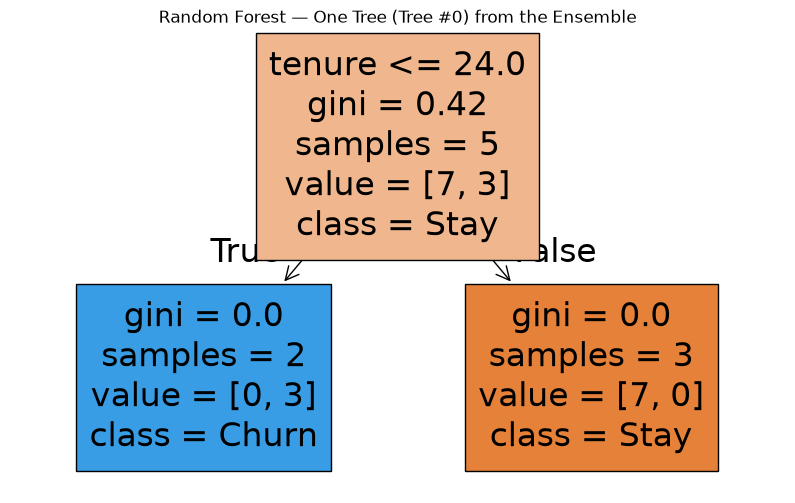

In [5]:
# Visualize one tree from the forest (say, tree #0)
plt.figure(figsize=(10, 6))
plot_tree(model.estimators_[0], feature_names=["tenure"], class_names=["Stay","Churn"], filled=True)
plt.title("Random Forest — One Tree (Tree #0) from the Ensemble")
plt.show()


## 1. Reading the tree image (Tree #0)

**Root node:** `tenure <= 24.0`, `gini = 0.42`, `samples = 5`, `value = [7, 3]`

Notice something odd - you have **10** original data points, but this tree's root says `samples = 5`. This is the fingerprint of **bagging**:

- Random Forest draws a **bootstrap sample** for each tree — same size as the original dataset (10), but **with replacement**.
- That means some rows get picked more than once, and some rows don't get picked at all.
- `samples = 5` = the number of *unique* original rows that ended up in this tree's bootstrap draw (the other 5 didn't get picked at all for this particular tree).
- `value = [7, 3]` = the **total weighted count** — sums to 10, not 5 — because duplicated rows count multiple times toward the class totals, even though only 5 unique rows are represented.

So Tree #0 essentially only "saw" half your data, some of it repeated. That's the randomness bagging introduces.

**Gini at root:**
$$Gini = 1 - (0.7)^2 - (0.3)^2 = 1 - 0.49 - 0.09 = 0.42$$
matches the 7:3 split exactly (7 "Stay", 3 "Churn" in its weighted sample).

**After the split at `tenure <= 24`:**
- Left (True, tenure ≤ 24): `value = [0, 3]`, gini = 0 → pure Churn leaf
- Right (False, tenure > 24): `value = [7, 0]`, gini = 0 → pure Stay leaf

Perfectly clean split — for *this tree's* bootstrap sample.

## 2. Why the forest's prediction differs from the actual label

```
Actual:      [1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Predicted:   [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
                          ↑
                    tenure = 12
Probability: [1, 1, 1, 1, 0.8, 0.2, 0, 0, 0, 0]
```

Point index 4 (`tenure = 12`, actual = 0/Stay) got predicted as **1/Churn**, with probability 0.8.

Here's the math: `predict_proba` for a Random Forest is just the **average of each tree's own predict_proba**:

$$P(\text{Churn} \mid x) = \frac{1}{5}\sum_{i=1}^{5} P_i(\text{Churn}\mid x)$$

For `tenure = 12`, apparently **4 out of 5 trees** voted "Churn" (giving proba near 1 each) and only 1 voted "Stay" — averaging to 0.8. This happens because different trees, trained on different bootstrap samples, drew their `tenure` threshold splits in slightly different places. Some trees' bootstrap draw may not have contained enough high-tenure/low-churn examples near that boundary to correctly learn the pattern — so they misclassify that point.

**This is the key intuition:** a single unconstrained Decision Tree would have memorized all 10 points perfectly (gini=0 leaves for everything, 100% training accuracy). The Random Forest, by design, *doesn't* perfectly fit the training data — because no individual tree sees all the data, and depth is capped. That's not a bug — it's literally the mechanism that reduces overfitting. You're trading perfect training fit for (hopefully) better generalization on unseen data.

## 3. Feature Importance = `[1.0]`

Trivial here — `tenure` is the *only* feature, so it gets 100% of the importance by definition. This will become meaningful once we move to 3 features on the real dataset.



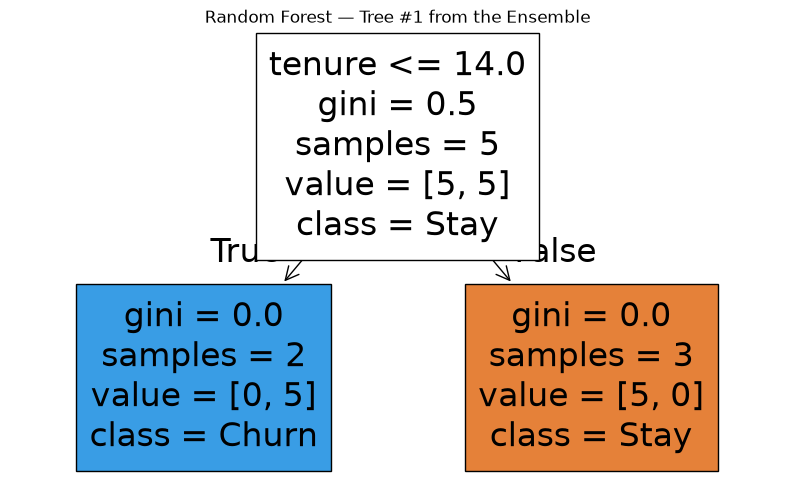

In [6]:
plt.figure(figsize=(10, 6))
plot_tree(model.estimators_[1], feature_names=["tenure"], class_names=["Stay","Churn"], filled=True)
plt.title("Random Forest — Tree #1 from the Ensemble")
plt.show()


## Tree #0 vs Tree #1

| | Tree #0 | Tree #1 |
|---|---|---|
| Split threshold | `tenure <= 24.0` | `tenure <= 14.0` |
| Root gini | 0.42 | 0.5 |
| Root `value` | [7, 3] | [5, 5] |
| Left leaf | [0, 3] Churn | [0, 5] Churn |
| Right leaf | [7, 0] Stay | [5, 0] Stay |

**Root gini = 0.5** here is the maximum possible for binary classification — this tree's bootstrap sample happened to draw an exactly balanced 5:5 mix of Stay/Churn, the most "impure"/uncertain starting point possible:
$$Gini = 1 - (0.5)^2 - (0.5)^2 = 1 - 0.25 - 0.25 = 0.5$$

**Why the threshold moved from 24 to 14:** Tree #0's bootstrap draw happened to contain rows where the natural Stay/Churn boundary sat around tenure=24. Tree #1's bootstrap draw — a *different* random resample with replacement — happened to contain rows where the cleanest split was at tenure=14. Neither tree saw the "true" full dataset; each just found the best split for *its own* random slice.

**Both trees still hit gini = 0.0 in both leaves.** That makes sense here because this toy dataset is essentially linearly separable on `tenure` alone — any reasonable threshold between the "churn cluster" (low tenure) and "stay cluster" (high tenure) will produce a clean split, regardless of exactly where the resample happened to draw its boundary.

**The bigger picture:** individually, both trees are confident and "correct-looking" on their own bootstrap sample. But they disagree with each other on where the *true* boundary is (14 vs 24). It's exactly this kind of disagreement, averaged across many trees, that gave you the earlier fractional probability (0.8) at `tenure=12` — some trees say Churn, some say Stay, and the forest reports the vote share instead of a single hard answer. A single Decision Tree can never produce that kind of probabilistic uncertainty on training data; only an ensemble can.



## Random Forest — Example 2: Real Telco Dataset

What's new here vs. Example 1

All 3 features (tenure, MonthlyCharges, TotalCharges) instead of just tenure — so feature_importances_ will actually be meaningful this time, not a trivial [1.0].
n_estimators=100 — a realistic forest size instead of 5 toy trees. More trees = more stable averaging, less variance in the final probabilities.
max_depth=4 — kept the same cap as your Decision Tree Example 2, so the comparison between the two models is apples-to-apples (same depth constraint, same features, same train/test split).

Comparing 3 models now: Logistic Regression (78% acc, 0.80 AUC) → Decision Tree (your numbers from before) → Random Forest (this one). The question we're building toward: does averaging many trees actually beat one tree's overfitting/variance problem? 

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import pandas as pd 

In [9]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv") 

In [10]:
# Recreate the binary target if it's missing
df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)  # or df.dropna(subset=["TotalCharges"])

In [12]:
print(df.columns.tolist())
print(df["Churn"].value_counts())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_binary']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
X = df[["tenure", "MonthlyCharges", "TotalCharges"]]
y = df["Churn_binary"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train) 

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [18]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.7970191625266146
Confusion Matrix:
 [[961  75]
 [211 162]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.93      0.87      1036
           1       0.68      0.43      0.53       373

    accuracy                           0.80      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.80      0.78      1409

AUC: 0.8397618702578488


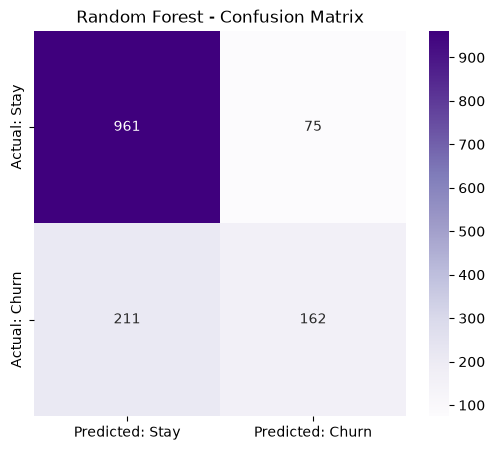

In [19]:
# Confusion matrix heatmap
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Predicted: Stay", "Predicted: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
plt.title("Random Forest - Confusion Matrix")
plt.savefig("../visuals/rf_confusion_matrix.png")
plt.show()

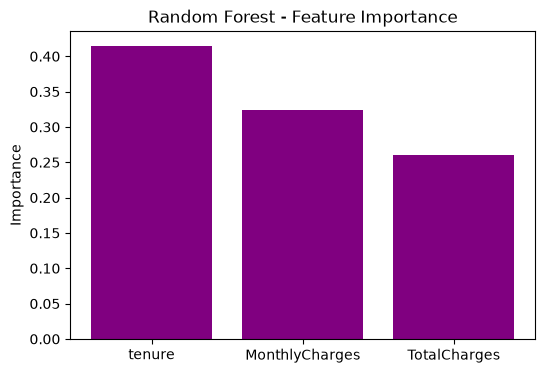

In [20]:
# Feature importance
importances_rf = rf_model.feature_importances_
features = ["tenure", "MonthlyCharges", "TotalCharges"]
plt.figure(figsize=(6,4))
plt.bar(features, importances_rf, color="purple")
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance")
plt.savefig("../visuals/rf_feature_importance.png")
plt.show()

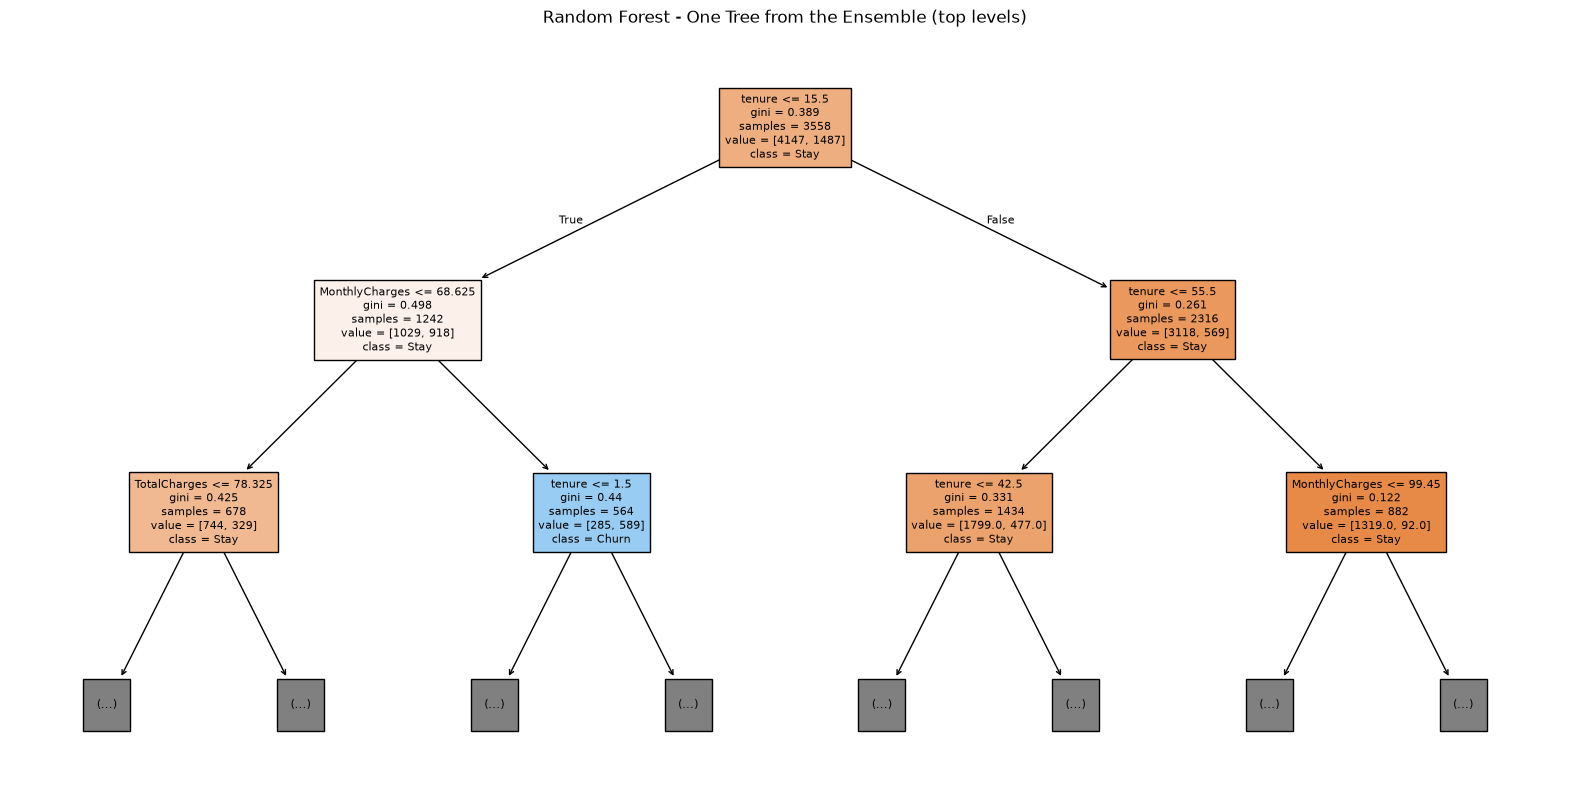

In [21]:
# Visualize one tree from the forest (top levels only)
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(rf_model.estimators_[0], feature_names=features,
          class_names=["Stay","Churn"], filled=True, max_depth=2, fontsize=8)
plt.title("Random Forest - One Tree from the Ensemble (top levels)")
plt.savefig("../visuals/rf_tree_sample.png")
plt.show()

## Explaining the Random Forest Output

### 1. Confusion Matrix — where the errors are

```
                Predicted: Stay   Predicted: Churn
Actual: Stay         961               75
Actual: Churn        211              162
```

- **TN = 961**, **FP = 75**, **FN = 211**, **TP = 162**
- Total test samples = 961+75+211+162 = **1409**

**Accuracy:**
$$\frac{TN+TP}{Total} = \frac{961+162}{1409} = \frac{1123}{1409} = 0.7970$$
Matches the printed `0.7970191625266146` exactly.

The big number to notice: **211 false negatives** — customers who actually churned but the model predicted "Stay." That's more than half of all actual churners (373 total) being missed. This is the same recall weakness pattern Logistic Regression had — Random Forest hasn't solved it, just shifted it slightly.

### 2. Precision / Recall / F1 — verifying the math

**Class 1 (Churn):**
$$Precision = \frac{TP}{TP+FP} = \frac{162}{162+75} = \frac{162}{237} = 0.6835 \approx 0.68$$
$$Recall = \frac{TP}{TP+FN} = \frac{162}{162+211} = \frac{162}{373} = 0.4343 \approx 0.43$$
$$F1 = \frac{2 \times P \times R}{P+R} = \frac{2 \times 0.6835 \times 0.4343}{0.6835+0.4343} = \frac{0.5937}{1.1178} = 0.531 \approx 0.53$$

**Class 0 (Stay):**
$$Precision = \frac{961}{961+211} = 0.8199 \approx 0.82 \qquad Recall = \frac{961}{961+75} = 0.9276 \approx 0.93$$

Both match your classification report exactly. Interpretation: the model is **very good at confirming who stays** (93% recall on Stay) but **mediocre at catching who churns** (43% recall on Churn) — it's biased toward the majority class, which is typical when a dataset is imbalanced (1036 Stay vs 373 Churn in the test set, roughly 74/26).

### 3. AUC = 0.8397

This is the most encouraging number here. AUC measures the model's ability to *rank* churners above non-churners across all possible thresholds — not just at the default 0.5 cutoff the confusion matrix uses. **0.84 vs Logistic Regression's 0.80** is a real, meaningful improvement: the forest's underlying probability estimates are better-separated even though the *hard predictions* at threshold=0.5 didn't dramatically improve accuracy (79.7% vs 78%). This is a classic pattern — ensembles usually improve probability calibration/ranking before they improve raw accuracy at a fixed threshold.

### 4. Feature Importance — now meaningful

```
tenure          ≈ 0.415
MonthlyCharges  ≈ 0.325
TotalCharges    ≈ 0.260
```

Unlike your toy example (`[1.0]`, trivial with one feature), this is now computed as: for every split across all ~100 trees, how much did splitting on that feature reduce weighted Gini impurity, averaged and normalized to sum to 1. `tenure` dominates — consistent with it being the root split in the visualized tree (and likely the root/near-root in most of the 100 trees), meaning it's the single strongest churn signal across the whole forest.

### 5. Reading the visualized tree (top levels)

**Root:** `tenure <= 15.5`, gini = 0.389, `value = [4147, 1487]`

Check the gini math:
$$p_0 = \frac{4147}{5634} = 0.7362, \quad p_1 = \frac{1487}{5634} = 0.2638$$
$$Gini = 1 - 0.7362^2 - 0.2638^2 = 1 - 0.5419 - 0.0696 = 0.3885 \approx 0.389 ✓$$

Note `samples = 3558` but `value` sums to 5634 — same bootstrap fingerprint as your toy example: `samples` counts unique original rows in this tree's bootstrap draw, `value` counts the weighted total (duplicates included).

Interesting sub-split: on the **True branch** (`tenure ≤ 15.5`), the second split is on `tenure ≤ 1.5`, and that leaf has `class = Churn` (`value = [285, 589]`) — the *only* churn-majority node visible in this tree. Translation: customers with **extremely low tenure (≤1.5 months) AND already past the 15.5-month threshold check** are the clearest churn signal this tree found. Very new customers churn disproportionately — a classic, intuitive churn pattern.

### 6. Comparison so far

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 78% | 79.7% |
| AUC | 0.80 | 0.84 |
| Churn Recall | — (you'd need to check) | 43% |

Random Forest improved AUC meaningfully and accuracy slightly. We're still missing your actual **Decision Tree Example 2** numbers though — you moved straight to Random Forest without pasting the Decision Tree's accuracy/confusion matrix/AUC output. Want to go back and paste those so we can do the full three-way table (Logistic Regression vs Decision Tree vs Random Forest)?

Now we have all three models. Let's verify the Decision Tree math, then do the full three-way comparison.

### Decision Tree — quick verification

```
TN=918, FP=118, FN=176, TP=197
```

**Accuracy:**
$$\frac{918+197}{1409} = \frac{1115}{1409} = 0.7913 ✓$$

**Churn (class 1) Precision/Recall:**
$$Precision = \frac{197}{197+118} = \frac{197}{315} = 0.6254 \approx 0.63$$
$$Recall = \frac{197}{197+176} = \frac{197}{373} = 0.5282 \approx 0.53$$

Both match your report exactly.

### Root node check
`tenure <= 16.5`, gini=0.39, `value=[4138,1496]`:
$$p_0=\frac{4138}{5634}=0.7345,\ p_1=0.2655$$
$$Gini=1-0.7345^2-0.2655^2=1-0.5395-0.0705=0.390 ✓$$

Almost identical root split to the Random Forest's single tree (`tenure<=15.5` there vs `16.5` here) — makes sense, since both are trained on the *full* dataset (this is the single Decision Tree, not a bootstrap sample), so they should agree closely on where the strongest signal splits.

---

## Three-Way Comparison

| Metric | Logistic Regression | Decision Tree | Random Forest |
|---|---|---|---|
| **Accuracy** | 0.78 | 0.7913 | **0.7970** |
| **AUC** | 0.80 | 0.8214 | **0.8398** |
| **Churn Precision** | — | 0.63 | 0.68 |
| **Churn Recall** | — | **0.53** | 0.43 |
| **Churn F1** | — | **0.57** | 0.53 |
| **False Negatives (missed churners)** | — | 176 | 211 |

### The key finding — and it's counterintuitive

**Random Forest has the best Accuracy and best AUC, but it's actually *worse* than the single Decision Tree at the one thing that matters most for churn: catching churners.**

- Decision Tree recall on churn = 0.53 → correctly flags 197/373 actual churners
- Random Forest recall on churn = 0.43 → correctly flags only 162/373 actual churners
- Random Forest's False Negatives jumped from 176 → 211, meaning it's **letting 35 more actual churners slip through undetected**, compared to the single tree

### Why did this happen? (the math reasoning)

Random Forest averages probabilities across 100 trees:
$$P(\text{Churn}) = \frac{1}{100}\sum_{i=1}^{100} P_i(\text{Churn})$$

Averaging **pulls probabilities toward the middle**. A single Decision Tree can produce a confident, extreme leaf probability (e.g., a pure `gini=0` leaf saying "this customer is 100% Churn"). But when you average 100 trees, very few customers end up with an averaged probability that clears the 0.5 threshold — most borderline cases get diluted toward ~0.3–0.5 instead of confidently crossing into "Churn."

Since Churn is the **minority class** (only ~26% of the data), this averaging effect disproportionately hurts the minority class: borderline churners get "voted down" toward the majority (Stay) by the ensemble, even when a single well-tuned tree might have caught them.

This is a real, well-known tradeoff: **Random Forest reduces variance and improves ranking quality (AUC) and overall accuracy, but at default threshold=0.5 it can be more conservative about predicting the minority class than a single tree.**

### What this means practically
If the business goal is "accuracy at threshold 0.5" or "best ranking of who's at risk" → Random Forest wins (AUC 0.84).
If the business goal is "catch as many actual churners as possible" → the single Decision Tree currently wins on recall, and you'd want to either:
- lower the classification threshold on the Random Forest (e.g., flag anyone with `P(Churn) > 0.3` instead of 0.5), or
- use `class_weight='balanced'` to force the forest to penalize missed churners more heavily.

